In [1]:
import numpy as np
import networkx as nx
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sparse import COO, random, triu
# %load_ext memory_profiler
plt.rc('figure', figsize=(4.0, 3.0))
sns.set_theme(style='white')
imgpath=Path('../../docs/user-guide/img/')

In [24]:
n_cols=5000
n_rows=25000
B = nx.bipartite.random_graph(n_cols,n_rows, .0005, seed=2)
n = list(B.nodes)[n_cols:]

X = COO.from_scipy_sparse(nx.bipartite.biadjacency_matrix(B, n)).astype(bool)
X

Format,coo
Data Type,bool
Shape,"(25000, 5000)"
nnz,62417
Density,0.000499336
Read-only,True
Size,1.0M
Storage ratio,0.01


## Sparse Squareform

We can use the identities in [Angeletti et al](https://hal.science/hal-02047514) to derive _sparse_-friendly versions of the [`scipy.spatial.distance.squareform`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.squareform.html) operations and laplacian/covariance/co-occurrence normalization (symmetric/correlation/cosine-similarity). 

In [25]:
from affinis.utils import _sq
from affinis.edgespace import sq_e_ij, sq_ij_e, csr_rows_idx
from sparse import diagonal, triu, stack

%psource sq_ij_e

def sq_ij_e(n: int, ij: tuple[Idx, Idx]) -> Idx:
    """Closed-form expression to map edge-to-node-pair indices.

    Get an edge index from a row-column index pai  upper-triangle of a
    symmetric matrix.

    Parameters:
        n: dimension of square/symmetric matrix
        ij: pair of row(s),column(s) indices in corresponding matrix.

    Returns:
        index of edge(s) from vector-representation
    """
    i, j = ij
    e = (n * (n - 1) / 2) - (n - i) * ((n - i) - 1) / 2 + j - i - 1
    return e.astype(int)
    # return _map_edge_to_nodes(n).inverse[ij]


In [26]:
%psource sq_e_ij

def sq_e_ij(n: int, e: Idx) -> tuple[Idx, Idx]:
    """Closed-form expression to map edge-to-node-pair indices.

    Get a row-column location in the upper-triangle of a symmetric
    matrix, given the linear index of it's unrolled vector representation.

    Parameters:
        n: dimension of square/symmetric matrix
        e: index of edge(s) from vector-representation

    Returns:
        pair of row(s),column(s) indices in corresponding matrix.
    """
    i = n - 2 - np.floor(np.sqrt(-8 * e + 4 * n * (n - 1) - 7) / 2.0 - 0.5)
    j = e + i + 1 - n * (n - 1) / 2 + (n - i) * ((n - i) - 1) / 2
    return i.astype(int), j.astype(int)
    # return _map_edge_to_nodes(n)[e]


In [27]:
from affinis.utils import sq2flat, flat2sq, _norm_diag
"""
from plum import dispatch 
from jaxtyping import Shaped
from typing import Any

@dispatch(precedence=1)
def sq2flat(A:Shaped[np.ndarray, "s s"]):
    n = min(A.shape[-1],A.shape[-2])
    return A[np.triu_indices(n, k=1)]

@dispatch
def sq2flat(A: Shaped[COO, "s s"]):
    n = min(A.shape[-1],A.shape[-2])
    # coord_mask = a.coords[0]<a.coords[1]
    # idxs=a.coords[:,coord_mask]
    # coords = sq_ij_e(n, idxs)
    # return COO(shape=[int(n*n/2-n/2),], coords=coords, data=a.data[coord_mask])
    a=triu(A, k=1)  # wow this works with ndim>2 as well! 
    coords = sq_ij_e(n, a.coords[-2:,:])  # which means I can too!
    shape = int(n*n/2-n/2)
   
    if a.ndim>2:  # maybe there's a slicing/indexing way to make implicit
        coords =  np.vstack([a.coords[0], coords])
        shape = (a.shape[0],shape)
    return COO(shape=shape, coords=coords, data=a.data)



def flat2sq(e):
    ## NOT CURRENTLY BATCH-DIM COMPATIBLE
    n = int(np.ceil(np.sqrt(e.shape[0] * 2)))
    # Check that e is of valid dimensions.
    if n * (n - 1) != e.shape[0] * 2:  # identical check from scipy
        raise ValueError(
            'Incompatible vector size. It must be a triangular number.'
        )
    tri_coords=sq_e_ij(n, e.coords[0])
    tri=COO(coords=tri_coords, shape=(n,n), data=e.data)
    return tri+tri.T
"""
def norm_diag_sprs(Sq):
    d=diagonal(Sq)
    tri = triu(Sq, k=1)
    d_a=d[triu(Sq).coords[0]]
    d_b=d[triu(Sq).coords[1]]
    # Do I need to worry about sqrt div? simSIMD uses Newton-Raphson...
    return COO(data=(triu(Sq, k=1).data+0.5)/(np.sqrt(d_a*d_b).todense()+1), coords=triu(Sq).coords, shape=Sq.shape) 
    
def sparse_cos(X):
    D = X.T@X
    return norm_diag_sprs(D) 
# from affinis.associations import ochiai

# norm_diag_sprs(G) + norm_diag_sprs(G).T + 


In [28]:
from affinis.associations import ochiai

-np.log(sq2flat(ochiai(X, pseudocts='min-connect')))

/home/rtbs/syncthing/nist-docs/code/thesis/affinis/.venv/lib/python3.12/site-packages/sparse/numba_backend/_umath.py:529: RuntimeWarning: divide by zero encountered in log
  fill_value_array = self.func(*zero_args, dtype=self.dtype, **self.kwargs)


Format,coo
Data Type,float64
Shape,"(12497500,)"
nnz,78148
Density,0.0062530906181236245
Read-only,True
Size,1.2M
Storage ratio,0.01


In [29]:
# diagonal(sparse_cos(X)).data
G = X.T@X
d = diagonal(G).todense()
G_e = sq2flat(G)
d_i, d_j = sq_e_ij(d.size, G_e.coords)

d_a=d[d_i[0]]
d_b=d[d_j[0]]
flat2sq(COO(data=(G_e.data+0.5)/(np.sqrt(d_a*d_b)+1), coords=G_e.coords, shape=G_e.shape))

# from sparse import outer
# outer(d,d)

# (d_a*d_b).nbytes/(outer(d,d).nbytes)
# G.nbytes
# G
# d[d_i]

Format,coo
Data Type,float64
Shape,"(5000, 5000)"
nnz,156296
Density,0.00625184
Read-only,True
Size,3.6M
Storage ratio,0.02


In [32]:
# np.random.rand(10,10)[??p.triu_indices(10, k=1)]
# sq2flat(np.random.rand(10,10))
X

Format,coo
Data Type,bool
Shape,"(25000, 5000)"
nnz,62417
Density,0.000499336
Read-only,True
Size,1.0M
Storage ratio,0.01


In [39]:
from affinis.associations import forest_pursuit

# %timeit forest_pursuit(X, mode='counts')

2.91 s ± 117 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [38]:
fp = forest_pursuit(X, mode='counts')

Format,coo
Data Type,int64
Shape,"(5000, 5000)"
nnz,78892
Density,0.00315568
Read-only,True
Size,1.8M
Storage ratio,0.01


### Testing fold/unfold Space Needs

In [26]:
from sparse import random
A = random((10000,10000))

%timeit flat2sq(sq2flat(A))
%timeit flat2sq(sq2flat(A.todense()))

207 ms ± 4.79 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
2.68 s ± 296 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [8]:
# %memit flat2sq(sq2flat(A))
# %memit _sq(_sq(A.todense()))

### Improving Cosine Sim Sparsity

In [9]:
from scipy.sparse import csc_array
from affinis.associations import ochiai
bigX = random((10000,5000), density=0.001)

# %memit sparse_cos(bigX) 
# %memit ochiai(csc_array(bigX.to_scipy_sparse()))


### Improving Edge ID extraction

Now we can make an explicit representation of the original data, as cliques. 
The _Desire-path Density_ model says that we should select a subgraph of each of these cliques, to aggregate for an overall (conditional) edge probability. 

In [10]:
from sparse import einsum

Xclique = sq2flat(einsum('bi,bo->bio', X, X))
Xclique

Format,coo
Data Type,bool
Shape,"(5000, 499500)"
nnz,62260
Density,2.492892892892893e-05
Read-only,True
Size,1.0M
Storage ratio,0.00


In [69]:
from scipy.sparse.csgraph import minimum_spanning_tree
# sq2flat(minimum_spanning_tree(flat2sq(Xclique.sum(axis=0)))).coords[0]
-np.log(flat2sq(Xclique.sum(axis=0))).fill_value

/home/rtbs/syncthing/nist-docs/code/thesis/affinis/.venv/lib/python3.12/site-packages/sparse/numba_backend/_umath.py:529: RuntimeWarning: divide by zero encountered in log
  fill_value_array = self.func(*zero_args, dtype=self.dtype, **self.kwargs)


np.float64(inf)

<Axes: ylabel='Count'>

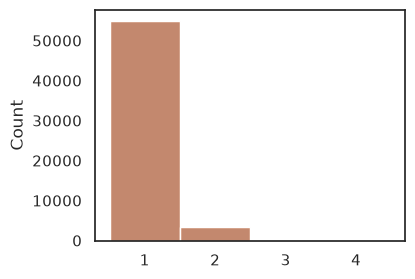

In [19]:
sns.histplot(data=(Xclique.sum(axis=0)).data, discrete=True)
sns.histplot(sq2flat(X.T.astype(int)@X.astype(int)).data, discrete=True)
# sq2flat(X.T@X).data

Let's get the LIL representation to make future application of Forest Pursuit easier. 
Now that we have a way to unroll batch tensors, we can compare the clique edge index retrieval via both that and the previous `itertools.combinations` way

In [59]:
# list(csr_rows_idx(random((10, 100)).tocsr()))[6].size

0

In [20]:
from itertools import combinations, islice
from affinis.utils import complete_edgelist_on_nodes
# %timeit 
def edge_candidates_einsum(X):
    # yield from (sq2flat(i).coords[0] for i in triu(einsum('bi,bo->bio', DTM, DTM), k=1))
    # yield from triu(einsum('bi,bo->bio', DTM, DTM), k=1) 
    # yield from (sq_ij_e(DTM.shape[1],i.coords) for i in einsum('bi,bo->bio', DTM, DTM))
    # yield from (i.coords for i in triu(einsum('bi,bo->bio', DTM, DTM), k=1))
    yield from csr_rows_idx(sq2flat(einsum('bi,bo->bio', X, X)).tocsr())

def edge_candidates_affinis(X):
    n = X.shape[1]1
    yield from (complete_edgelist_on_nodes(n,i) for i in csr_rows_idx(X.tocsr()))

    
def edge_candidates_itertl(X):
    yield from (sq_ij_e(X.shape[1],np.array(list(combinations(i.tolist(),2))).T) 
     if len(i)>1
     else np.array([])
     for i in csr_rows_idx(X.tocsr())
    )

In [21]:
list(islice(edge_candidates_affinis(X),3))

[array([321063, 321507, 321530, 321534, 359228, 359251, 359255, 495781,
        495785, 497487]),
 array([186364, 186512, 186514, 186855, 186893, 186948, 261252, 261254,
        261595, 261633, 261688, 352348, 352689, 352727, 352782, 353770,
        353808, 353863, 479637, 479692, 486513]),
 array([  6056,   6125,   6216,   6654,   6924,   6962,  80498,  80589,
         81027,  81297,  81335, 141309, 141747, 142017, 142055, 214547,
        214817, 214855, 449366, 449404, 498409])]

In [22]:
list(islice(edge_candidates_einsum(X), 3))

[array([321063, 321507, 321530, 321534, 359228, 359251, 359255, 495781,
        495785, 497487]),
 array([186364, 186512, 186514, 186855, 186893, 186948, 261252, 261254,
        261595, 261633, 261688, 352348, 352689, 352727, 352782, 353770,
        353808, 353863, 479637, 479692, 486513]),
 array([  6056,   6125,   6216,   6654,   6924,   6962,  80498,  80589,
         81027,  81297,  81335, 141309, 141747, 142017, 142055, 214547,
        214817, 214855, 449366, 449404, 498409])]

In [23]:
list(islice(edge_candidates_itertl(X), 3))

[array([321063, 321507, 321530, 321534, 359228, 359251, 359255, 495781,
        495785, 497487]),
 array([186364, 186512, 186514, 186855, 186893, 186948, 261252, 261254,
        261595, 261633, 261688, 352348, 352689, 352727, 352782, 353770,
        353808, 353863, 479637, 479692, 486513]),
 array([  6056,   6125,   6216,   6654,   6924,   6962,  80498,  80589,
         81027,  81297,  81335, 141309, 141747, 142017, 142055, 214547,
        214817, 214855, 449366, 449404, 498409])]

In [42]:
Xclique.sum(axis=0).todense()[next(edge_candidates_einsum(X))]
# COO.to

array([3, 2, 1, 1, 1, 1, 1, 1, 2, 1])

### Testing Edge ID extraction

In [24]:
from collections import deque

%timeit deque(edge_candidates_affinis(X), maxlen=0)
%timeit deque(edge_candidates_einsum(X), maxlen=0)
%timeit deque(edge_candidates_itertl(X), maxlen=0)

65.2 ms ± 1.74 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
13.7 ms ± 492 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
36 ms ± 170 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


Einsum in `sparse` is a huge savings, now that the `squareform` operator works natively!